In [217]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.model_selection import RandomizedSearchCV,train_test_split
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

In [218]:
df=pd.read_csv("data/stud.csv")

In [219]:
x=df.drop(columns=["math_score"])

In [220]:
y=df["math_score"]
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [221]:
num_features=x.select_dtypes(include="number").columns
cat_features=x.select_dtypes(include="O").columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

num_transformer=StandardScaler()
cat_transformer=OneHotEncoder()

preprocessor= ColumnTransformer(
    [
        ("OneHotEncoder",cat_transformer,cat_features),
        ("StandardScaler",num_transformer,num_features),
    ]
)

In [222]:
x=preprocessor.fit_transform(x)

In [223]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [224]:
def eval_model(true,pred):
    mae=mean_absolute_error(true,pred)
    mse=mean_squared_error(true,pred)
    rmse=np.sqrt(mean_squared_error(true,pred))
    r2=r2_score(true,pred)

    return mae,mse,rmse,r2



In [225]:
models={
    "LinearRegression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "KNeighborsRegressor":KNeighborsRegressor(),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "RandomForestRegressor":RandomForestRegressor(),
    "XGBRegressor":XGBRegressor(),
    "CatBoostRegressor":CatBoostRegressor(),
    "AdaBoostRegressor":AdaBoostRegressor()
}

model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(xtrain,ytrain)
    
    ytrain_pred=model.predict(xtrain)
    ytest_pred=model.predict(xtest)

    trainmae,trainmse,trainrmse,trainr2=eval_model(ytrain,ytrain_pred)
    testmae,testmse,testrmse,testr2=eval_model(ytest,ytest_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Training set")
    print("MAE:{:.4f}".format(trainmae))
    print("MSE:{:.4f}".format(trainmse))
    print("RMSE:{:.4f}".format(trainrmse))
    print("R2:{:.4f}".format(trainr2))

    print("--------------------------------------------------")

    print("Testing set")
    print("MAE:{:.4f}".format(testmae))
    print("MSE:{:.4f}".format(testmse))
    print("RMSE:{:.4f}".format(testrmse))
    print("R2:{:.4f}".format(testr2))
    r2_list.append(testr2)
    print("="*35)
    print("\n")

LinearRegression
Training set
MAE:4.2667
MSE:28.3349
RMSE:5.3231
R2:0.8743
--------------------------------------------------
Testing set
MAE:4.2148
MSE:29.0952
RMSE:5.3940
R2:0.8804


Lasso
Training set
MAE:5.2063
MSE:43.4784
RMSE:6.5938
R2:0.8071
--------------------------------------------------
Testing set
MAE:5.1579
MSE:42.5064
RMSE:6.5197
R2:0.8253


Ridge
Training set
MAE:4.2650
MSE:28.3378
RMSE:5.3233
R2:0.8743
--------------------------------------------------
Testing set
MAE:4.2111
MSE:29.0563
RMSE:5.3904
R2:0.8806


KNeighborsRegressor
Training set
MAE:4.5167
MSE:32.5776
RMSE:5.7077
R2:0.8555
--------------------------------------------------
Testing set
MAE:5.6210
MSE:52.6066
RMSE:7.2530
R2:0.7838


DecisionTreeRegressor
Training set
MAE:0.0187
MSE:0.0781
RMSE:0.2795
R2:0.9997
--------------------------------------------------
Testing set
MAE:6.2150
MSE:59.7050
RMSE:7.7269
R2:0.7546


RandomForestRegressor
Training set
MAE:1.8270
MSE:5.3234
RMSE:2.3073
R2:0.9764
-----------

In [226]:
pd.DataFrame(list(zip(model_list,r2_list)), columns=["Model Name","R2 Score"]).sort_values(by=["R2 Score"],ascending=False)

,Model Name,R2 Score
2,Ridge,0.880593
0,LinearRegression,0.880433
7,CatBoostRegressor,0.851632
5,RandomForestRegressor,0.847931
8,AdaBoostRegressor,0.846678
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,KNeighborsRegressor,0.783813
4,DecisionTreeRegressor,0.754642


Text(0, 0.5, 'Predicted')

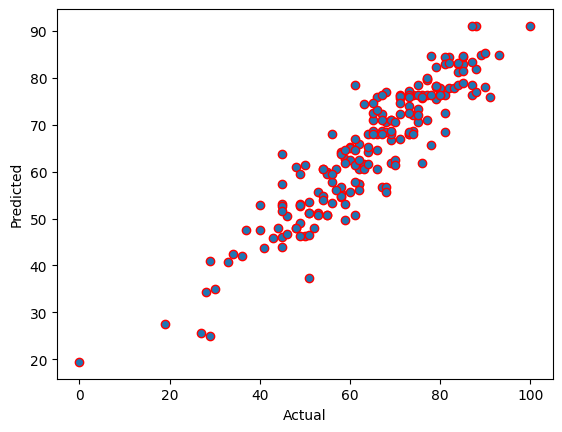

In [231]:
plt.scatter(ytest,ytest_pred,edgecolors='r')
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='math_score'>

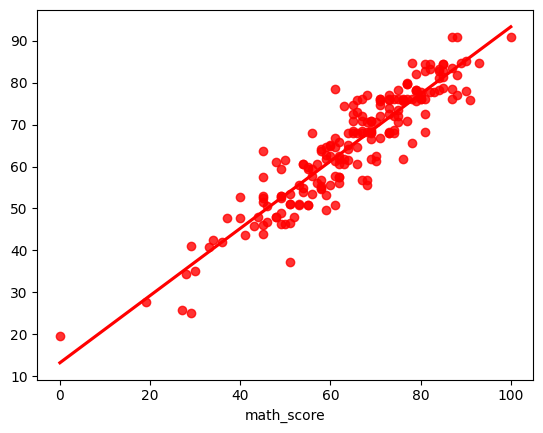

In [229]:
sns.regplot(x=ytest,y=ytest_pred,ci=None,color="r")

In [233]:
pred=pd.DataFrame({'Actual value':ytest,'Predicted value':ytest_pred,'Difference':ytest-ytest_pred})
pred

,Actual value,Predicted value,Difference
521,91,75.929134,15.070866
737,53,55.624294,-2.624294
740,80,77.150289,2.849711
660,74,76.227642,-2.227642
411,84,82.877419,1.122581
...,...,...,...
408,52,47.895062,4.104938
332,62,56.033113,5.966887
208,74,67.912281,6.087719
613,65,68.000000,-3.000000


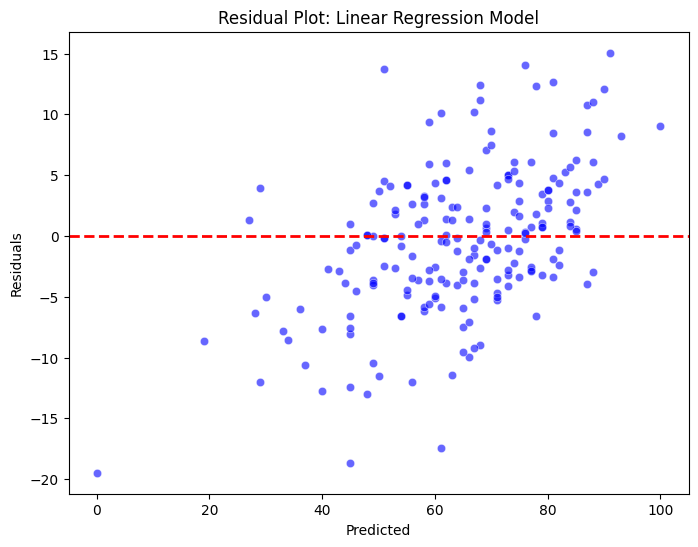

In [234]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pred["Actual value"], y=pred["Difference"], alpha=0.6, color='blue')

plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot: Linear Regression Model")

plt.show()